# BBbar 2D Poisson fit with iminuit

This notebook runs only the final **iminuit** stage of the BBbar weight tuning.

It:

1. loads the run/channel MC and data;
2. applies PID corrections and classifies MC;
3. builds a **fixed** fit-bin mask from raw nominal MC counts;
4. reads starting values from an Optuna JSON output or accepts manual values;
5. runs MIGRAD, HESSE, and optionally MINOS;
6. displays the covariance/correlation results and saves them to JSON.

The objective is the joint 2D Poisson deviance, so the Minuit error definition is `errordef = 1` (Δdeviance = 1 for a one-parameter asymptotic 68% interval).


In [2]:
# Uncomment if iminuit is not already installed in this environment.
# %pip install iminuit
%load_ext autoreload
%autoreload 2

import json
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Mapping, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import uproot
from iminuit import Minuit

import sys
sys.path.append('/home/belle/zhangboy/inclusive_R_D/')
import utilities as util


## 1. User configuration

Set `OPTUNA_JSON_PATH = None` to use only the manual initial values.

Manual entries may use either the MC category names or the safe Minuit parameter names. Manual values override values read from JSON.


In [10]:
# Data configuration
RUN = "run1"                  # "run1" or "run2"
CHANNEL = "e"                 # "e" or "mu"
MODE_REPLACEMENT = False

# Starting-value configuration
USE_OPTUNA_JSON = False
OPTUNA_JSON_PATH = Path(
    f"best_bbbar_weights_poisson_2d_{RUN}_{CHANNEL}.json"
)

# These values override JSON values when the dictionary is nonempty.
# Keys may be safe parameter names or full MC category names.
MANUAL_INITIAL_VALUES = {
    "measured": 2.2,
    "unmeasured_2body": 0.1,
    "unmeasured_3body": 0.5,
    "unmeasured_4body": 0.01,
    "unmeasured_5plus": 0.01,
}

RUN_MINOS = False
MINIMUM_RAW_MC_EVENTS = 1
LUMINOSITY_SCALE = 0.25

OUTPUT_JSON_PATH = Path(
    f"best_bbbar_weights_poisson_2d_{RUN}_{CHANNEL}_"
    f"replace{MODE_REPLACEMENT}_minuit.json"
)

TUNE_WEIGHT_COL = "BB_weight"
BASE_WEIGHT_COL = "__weight__"
PID_WEIGHT_COL = "total_PID_weight"


## 2. Fit parameters and ranges

The fake-D normalization and semileptonic weight remain fixed, matching the latest configuration.


In [8]:
@dataclass(frozen=True)
class JointLikelihoodTarget:
    x_variable: str
    x_bins: np.ndarray
    y_variable: str
    y_bins: np.ndarray
    cut: str = ""


@dataclass(frozen=True)
class ParameterSpec:
    category: str
    lower: float
    upper: float


PARAMETER_SPECS: Dict[str, ParameterSpec] = {
    "measured": ParameterSpec(
        "BBbar_measured_hadronic", 0.5, 5.0
    ),
    "unmeasured_2body": ParameterSpec(
        "BBbar_unmeasured:2-body", 0.01, 5.0
    ),
    "unmeasured_3body": ParameterSpec(
        "BBbar_unmeasured:3-body", 0.01, 1.0
    ),
    "unmeasured_4body": ParameterSpec(
        "BBbar_unmeasured:4-body", 0.001, 1.0
    ),
    "unmeasured_5plus": ParameterSpec(
        "BBbar_unmeasured:5+-body", 0.001, 0.5
    ),
}

FIXED_WEIGHTS = {
    "BBbar_semileptonic": 1.0,
    "bkg_fakeD": 0.87,
}

CATEGORIES = [
    "bkg_fakeD",
    "BBbar_measured_hadronic",
    "BBbar_semileptonic",
    "BBbar_unmeasured:2-body",
    "BBbar_unmeasured:3-body",
    "BBbar_unmeasured:4-body",
    "BBbar_unmeasured:5+-body",
]

joint_target = JointLikelihoodTarget(
    x_variable="B0_recMissM2",
    x_bins=np.linspace(-4.0, 10.0, 21),
    y_variable="p_D_l",
    y_bins=np.linspace(0.2, 4.0, 21),
    cut=(
        "1.855 < D_M < 1.885 "
        "and fakeD_prob < 0.1 and sig_prob < 0.1"
    ),
)

joint_target


JointLikelihoodTarget(x_variable='B0_recMissM2', x_bins=array([-4. , -3.3, -2.6, -1.9, -1.2, -0.5,  0.2,  0.9,  1.6,  2.3,  3. ,
        3.7,  4.4,  5.1,  5.8,  6.5,  7.2,  7.9,  8.6,  9.3, 10. ]), y_variable='p_D_l', y_bins=array([0.2 , 0.39, 0.58, 0.77, 0.96, 1.15, 1.34, 1.53, 1.72, 1.91, 2.1 ,
       2.29, 2.48, 2.67, 2.86, 3.05, 3.24, 3.43, 3.62, 3.81, 4.  ]), cut='1.855 < D_M < 1.885 and fakeD_prob < 0.1 and sig_prob < 0.1')

## 3. Histogram and likelihood functions

The support mask is calculated once from raw, unweighted MC counts. It is not recalculated as Minuit changes the weights.


In [5]:
def safe_query(df: pd.DataFrame, cut: str) -> pd.DataFrame:
    if not cut or not cut.strip():
        return df
    return df.query(cut, engine="python")


def histogram2d(
    x: np.ndarray,
    y: np.ndarray,
    x_bins: np.ndarray,
    y_bins: np.ndarray,
    weights: Optional[np.ndarray] = None,
) -> np.ndarray:
    hist, _, _ = np.histogram2d(
        x=x,
        y=y,
        bins=[x_bins, y_bins],
        weights=weights,
    )
    return hist.astype(float)


def get_data_histogram(
    df_data: pd.DataFrame,
    target: JointLikelihoodTarget,
) -> np.ndarray:
    selected = safe_query(df_data, target.cut)
    return histogram2d(
        selected[target.x_variable].to_numpy(dtype=float),
        selected[target.y_variable].to_numpy(dtype=float),
        target.x_bins,
        target.y_bins,
    )


def get_raw_mc_support_histogram(
    samples_mc: Mapping[str, pd.DataFrame],
    target: JointLikelihoodTarget,
) -> np.ndarray:
    shape = (len(target.x_bins) - 1, len(target.y_bins) - 1)
    total = np.zeros(shape, dtype=float)

    for df_sample in samples_mc.values():
        if df_sample is None or df_sample.empty:
            continue

        selected = safe_query(df_sample, target.cut)
        if selected.empty:
            continue

        total += histogram2d(
            selected[target.x_variable].to_numpy(dtype=float),
            selected[target.y_variable].to_numpy(dtype=float),
            target.x_bins,
            target.y_bins,
        )

    return total


def get_weighted_mc_histogram(
    samples_mc: Mapping[str, pd.DataFrame],
    target: JointLikelihoodTarget,
) -> np.ndarray:
    shape = (len(target.x_bins) - 1, len(target.y_bins) - 1)
    total = np.zeros(shape, dtype=float)

    for df_sample in samples_mc.values():
        if df_sample is None or df_sample.empty:
            continue

        selected = safe_query(df_sample, target.cut)
        if selected.empty:
            continue

        weights = np.ones(len(selected), dtype=float)

        for column in (
            BASE_WEIGHT_COL,
            PID_WEIGHT_COL,
            TUNE_WEIGHT_COL,
        ):
            if column in selected.columns:
                weights *= selected[column].to_numpy(dtype=float)

        weights *= float(LUMINOSITY_SCALE)

        if np.any(~np.isfinite(weights)):
            return np.full(shape, np.nan, dtype=float)

        total += histogram2d(
            selected[target.x_variable].to_numpy(dtype=float),
            selected[target.y_variable].to_numpy(dtype=float),
            target.x_bins,
            target.y_bins,
            weights=weights,
        )

    return total


def poisson_deviance(
    observed: np.ndarray,
    expected: np.ndarray,
) -> float:
    """Return -2 log(L/L_saturated) for independent Poisson bins."""
    observed = np.asarray(observed, dtype=float)
    expected = np.asarray(expected, dtype=float)

    if observed.shape != expected.shape:
        raise ValueError(
            f"Histogram shapes differ: {observed.shape} "
            f"and {expected.shape}."
        )

    if (
        np.any(~np.isfinite(observed))
        or np.any(~np.isfinite(expected))
    ):
        return np.inf

    if np.any(observed < 0):
        raise ValueError("Observed counts cannot be negative.")

    if np.any(expected < 0):
        return np.inf

    if np.any((observed > 0) & (expected <= 0)):
        return np.inf

    terms = expected - observed
    positive = observed > 0

    terms[positive] += observed[positive] * np.log(
        observed[positive] / expected[positive]
    )

    return float(2.0 * np.sum(terms))


## 4. Load MC and data

This cell uses the same input paths, preselection, PID correction, and trees as the script version.


In [6]:
if RUN not in {"run1", "run2"}:
    raise ValueError("RUN must be 'run1' or 'run2'.")

if CHANNEL not in {"e", "mu"}:
    raise ValueError("CHANNEL must be 'e' or 'mu'.")

columns = util.all_relevant_variables

pre_cut = (
    "(B0_roeMbc_my_mask > 5)"
    " & (-4 < B0_roeDeltae_my_mask)"
    " & (B0_roeDeltae_my_mask < 1)"
    " & (B0_dr < 0.1)"
)

input_file = (
    "/home/belle/zhangboy/inclusive_R_D/"
    f"Samples/4S_{RUN}_deimos_BDT_{CHANNEL}_3.root"
)

mc_tree = f"MC_{CHANNEL}_comb"
data_tree = f"Data_{CHANNEL}_comb"

print("Input:", input_file)
print("MC tree:", mc_tree)
print("Data tree:", data_tree)

mc_combined = uproot.concatenate(
    [f"{input_file}:{mc_tree}"],
    library="pd",
    cut=pre_cut,
    filter_branch=lambda branch: branch.name in columns,
)

data_combined = uproot.concatenate(
    [f"{input_file}:{data_tree}"],
    library="pd",
    cut=pre_cut,
    filter_branch=lambda branch: branch.name in columns,
)

mc_combined = util.apply_pid_corrections(
    df=mc_combined,
    run=RUN,
    channel=CHANNEL,
    corr_col_name=PID_WEIGHT_COL,
)

print(f"Loaded MC rows:   {len(mc_combined):,}")
print(f"Loaded data rows: {len(data_combined):,}")


Input: /home/belle/zhangboy/inclusive_R_D/Samples/4S_run1_deimos_BDT_e_3.root
MC tree: MC_e_comb
Data tree: Data_e_comb
Required variables: ['ell_BFbrems_charge', 'ell_BFbrems_p', 'ell_BFbrems_cosTheta', 'ell_BFbrems_PDG', 'ell_BFbrems_mcPDG']
Required variables: ['K_charge', 'K_p', 'K_cosTheta', 'K_PDG', 'K_mcPDG']
Required variables: ['pi1_charge', 'pi1_p', 'pi1_cosTheta', 'pi1_PDG', 'pi1_mcPDG']
Required variables: ['pi2_charge', 'pi2_p', 'pi2_cosTheta', 'pi2_PDG', 'pi2_mcPDG']
Loaded MC rows:   646,231
Loaded data rows: 132,705


## 5. Classify MC and construct the fixed fit mask


Included bins: 171 / 400
Included data events: 27887
Excluded data events: 2
Raw MC events in included bins: 150463


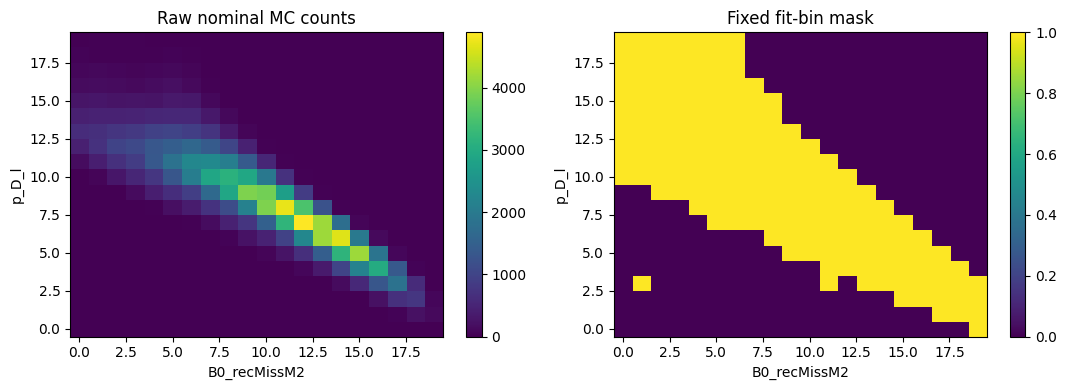

In [7]:
samples_base = util.classify_mc_dict(
    mc_combined,
    CHANNEL,
    template=False,
)

data_hist = get_data_histogram(
    data_combined,
    joint_target,
)

raw_mc_hist = get_raw_mc_support_histogram(
    samples_base,
    joint_target,
)

fit_mask = raw_mc_hist >= MINIMUM_RAW_MC_EVENTS

if not np.any(fit_mask):
    raise RuntimeError("No bins pass the raw-MC requirement.")

print(f"Included bins: {fit_mask.sum()} / {fit_mask.size}")
print(f"Included data events: {data_hist[fit_mask].sum():.0f}")
print(f"Excluded data events: {data_hist[~fit_mask].sum():.0f}")
print(f"Raw MC events in included bins: {raw_mc_hist[fit_mask].sum():.0f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

image0 = axes[0].imshow(
    raw_mc_hist.T,
    origin="lower",
    aspect="auto",
)
axes[0].set_title("Raw nominal MC counts")
axes[0].set_xlabel(joint_target.x_variable)
axes[0].set_ylabel(joint_target.y_variable)
fig.colorbar(image0, ax=axes[0])

image1 = axes[1].imshow(
    fit_mask.T,
    origin="lower",
    aspect="auto",
    vmin=0,
    vmax=1,
)
axes[1].set_title("Fixed fit-bin mask")
axes[1].set_xlabel(joint_target.x_variable)
axes[1].set_ylabel(joint_target.y_variable)
fig.colorbar(image1, ax=axes[1])

plt.tight_layout()
plt.show()


## 6. Read or enter the initial values

Recognized JSON layouts include:

- the original Optuna output with top-level `best_weights`;
- the combined script output with `optuna.best_weights`;
- a previous Minuit output with `minuit.best_weights`.

Manual entries override JSON entries.


In [12]:
def find_weight_map(payload: Mapping) -> Mapping[str, float]:
    candidates = [
        payload.get("optuna", {}).get("best_weights"),
        payload.get("best_weights"),
        payload.get("fitted_weights"),
        payload.get("minuit", {}).get("best_weights"),
    ]

    for candidate in candidates:
        if isinstance(candidate, Mapping):
            return candidate

    raise KeyError(
        "Could not find best_weights/fitted_weights in the JSON file."
    )


def normalize_initial_values(
    source: Mapping[str, float],
) -> Dict[str, float]:
    normalized = {}

    for safe_name, spec in PARAMETER_SPECS.items():
        if spec.category in source:
            value = source[spec.category]
        elif safe_name in source:
            value = source[safe_name]
        else:
            raise KeyError(
                f"Missing initial value for {safe_name!r} "
                f"({spec.category!r})."
            )

        value = float(value)

        if not spec.lower <= value <= spec.upper:
            raise ValueError(
                f"Initial value {value} for {safe_name} is outside "
                f"[{spec.lower}, {spec.upper}]."
            )

        normalized[spec.category] = value

    return normalized


starting_source = {}

if USE_OPTUNA_JSON:
    if OPTUNA_JSON_PATH is None:
        raise ValueError(
            "Set OPTUNA_JSON_PATH or set USE_OPTUNA_JSON=False."
        )

    with Path(OPTUNA_JSON_PATH).open() as input_file_handle:
        optuna_payload = json.load(input_file_handle)

    starting_source.update(find_weight_map(optuna_payload))
    print(f"Loaded initial values from {OPTUNA_JSON_PATH}")

# Manual values override values loaded from JSON.
starting_source.update(MANUAL_INITIAL_VALUES)

initial_weights = normalize_initial_values(starting_source)

# Add the fixed parameters after validating the fitted parameters.
initial_weights.update(FIXED_WEIGHTS)

initial_weights_table = pd.DataFrame.from_dict(
    initial_weights,
    orient="index",
    columns=["initial_value"],
)

initial_weights_table.index.name = "category"

initial_weights_table["fixed"] = (
    initial_weights_table.index.isin(FIXED_WEIGHTS)
)

display(initial_weights_table)

,initial_value,fixed
category,,
BBbar_measured_hadronic,2.20,False
BBbar_unmeasured:2-body,0.10,False
BBbar_unmeasured:3-body,0.50,False
BBbar_unmeasured:4-body,0.01,False
BBbar_unmeasured:5+-body,0.01,False
BBbar_semileptonic,1.00,True
bkg_fakeD,0.87,True


## 7. Define the Minuit objective

The utility function is called at every Minuit point. The fixed fake-D scale is explicitly assigned after BBbar reweighting.


In [13]:
replacement_map = (
    util.hadronicB_replacement_map
    if MODE_REPLACEMENT
    else None
)


def apply_category_weights(
    samples_base: Dict[str, pd.DataFrame],
    weights: Mapping[str, float],
) -> Dict[str, pd.DataFrame]:
    samples_weighted = util.reweight_BBbar_background(
        samples_base,
        weight_map=dict(weights),
        out_weight_col=TUNE_WEIGHT_COL,
        weight_ell_side=True,
        verbose=False,
        cap_nbody=5,
        warn_missing_weight_keys=True,
        D_replacement_map=replacement_map,
        ell_replacement_map=replacement_map,
    )

    # Enforce the independently determined fake-D normalization.
    if "bkg_fakeD" in samples_weighted:
        samples_weighted["bkg_fakeD"][TUNE_WEIGHT_COL] = float(
            weights["bkg_fakeD"]
        )

    return samples_weighted


def evaluate_weights(weights: Mapping[str, float]) -> float:
    samples_weighted = apply_category_weights(
        samples_base,
        weights,
    )

    mc_hist = get_weighted_mc_histogram(
        samples_weighted,
        joint_target,
    )

    return poisson_deviance(
        data_hist[fit_mask],
        mc_hist[fit_mask],
    )


parameter_names = tuple(PARAMETER_SPECS)


def minuit_cost(*parameter_values: float) -> float:
    weights = dict(FIXED_WEIGHTS)

    for name, value in zip(parameter_names, parameter_values):
        category = PARAMETER_SPECS[name].category
        weights[category] = float(value)

    return evaluate_weights(weights)


# The function returns -2 log(L/L_saturated), not plain -log(L).
minuit_cost.errordef = 1.0

initial_deviance = evaluate_weights(initial_weights)
print(f"Initial Poisson deviance: {initial_deviance:.6f}")


Initial Poisson deviance: 477.042566


## 8. Run MIGRAD and HESSE


In [14]:
start_values = [
    initial_weights[PARAMETER_SPECS[name].category]
    for name in parameter_names
]

minuit = Minuit(
    minuit_cost,
    *start_values,
    name=parameter_names,
)

for name, start in zip(parameter_names, start_values):
    spec = PARAMETER_SPECS[name]
    minuit.limits[name] = (spec.lower, spec.upper)

    # Initial numerical step size, not the final uncertainty.
    minuit.errors[name] = max(
        0.01 * (spec.upper - spec.lower),
        0.1 * start,
    )

minuit.strategy = 1
minuit.migrad()
minuit.hesse()

display(minuit.fmin)
display(minuit.params)

if minuit.covariance is not None:
    display(minuit.covariance)


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 469.9                      │              Nfcn = 284              │
│ EDM = 6.22e-07 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘

,Name,Value,Hesse Error,Minos Error-,Minos Error+,Limit-,Limit+,Fixed
0,measured,2.19,0.06,,,0.5,5,
1,unmeasured_2body,0.01,0.11,,,0.01,5,
2,unmeasured_3body,0.52,0.13,,,0.01,1,
3,unmeasured_4body,0.001,0.034,,,0.001,1,
4,unmeasured_5plus,0.07,0.05,,,0.001,0.5,


,measured,unmeasured_2body,unmeasured_3body,unmeasured_4body,unmeasured_5plus
measured,0.00416,-0.003e-6,-0.006 (-0.720),-0.3e-9,0.0006 (0.203)
unmeasured_2body,-0.003e-6,1.36e-08,-0.004e-6,-0,-0
unmeasured_3body,-0.006 (-0.720),-0.004e-6,0.0167,-1.7e-9,-0.0047 (-0.754)
unmeasured_4body,-0.3e-9,-0,-1.7e-9,6.82e-10,-0.8e-9
unmeasured_5plus,0.0006 (0.203),-0,-0.0047 (-0.754),-0.8e-9,0.00238


## 9. Run MINOS profile intervals

MINOS can be substantially slower because it profiles all other parameters for each interval.


In [ ]:
if RUN_MINOS:
    if not minuit.valid:
        print("Skipping MINOS because MIGRAD did not find a valid minimum.")
    else:
        try:
            minuit.minos()
        except RuntimeError as error:
            print(f"MINOS failed: {error}")

display(minuit.params)

if len(minuit.merrors) > 0:
    display(minuit.merrors)


## 10. Inspect fitted weights and correlations


In [ ]:
fitted_by_category = {
    PARAMETER_SPECS[name].category: float(minuit.values[name])
    for name in parameter_names
}

best_weights = {
    **fitted_by_category,
    **FIXED_WEIGHTS,
}

summary_rows = []

for name in parameter_names:
    row = {
        "parameter": name,
        "category": PARAMETER_SPECS[name].category,
        "value": float(minuit.values[name]),
        "hesse_error": float(minuit.errors[name]),
        "minos_lower": np.nan,
        "minos_upper": np.nan,
    }

    if name in minuit.merrors:
        row["minos_lower"] = float(minuit.merrors[name].lower)
        row["minos_upper"] = float(minuit.merrors[name].upper)

    summary_rows.append(row)

fit_summary = pd.DataFrame(summary_rows).set_index("parameter")
display(fit_summary)

print("Valid minimum:", minuit.valid)
print("Accurate covariance:", minuit.accurate)
print("EDM:", minuit.fmin.edm)
print(
    "Has parameters at limit:",
    minuit.fmin.has_parameters_at_limit,
)
print(
    "Positive-definite covariance:",
    minuit.fmin.has_posdef_covar,
)


In [ ]:
if minuit.covariance is not None:
    correlation = minuit.covariance.correlation()
    correlation_array = np.array(
        [
            [float(correlation[a, b]) for b in parameter_names]
            for a in parameter_names
        ]
    )

    fig, ax = plt.subplots(figsize=(8, 7))
    image = ax.imshow(
        correlation_array,
        vmin=-1,
        vmax=1,
        cmap="coolwarm",
    )

    ax.set_xticks(range(len(parameter_names)))
    ax.set_yticks(range(len(parameter_names)))
    ax.set_xticklabels(parameter_names, rotation=45, ha="right")
    ax.set_yticklabels(parameter_names)

    for i in range(len(parameter_names)):
        for j in range(len(parameter_names)):
            ax.text(
                j,
                i,
                f"{correlation_array[i, j]:.2f}",
                ha="center",
                va="center",
                color=(
                    "white"
                    if abs(correlation_array[i, j]) > 0.55
                    else "black"
                ),
            )

    ax.set_title("Minuit parameter correlation matrix")
    fig.colorbar(image, ax=ax, label="Correlation")
    plt.tight_layout()
    plt.show()
else:
    print("No covariance matrix is available.")


## 11. Save Minuit results


In [ ]:
def json_safe(value):
    if isinstance(value, Mapping):
        return {
            str(key): json_safe(item)
            for key, item in value.items()
        }
    if isinstance(value, (list, tuple)):
        return [json_safe(item) for item in value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    return value


names = list(parameter_names)

covariance_output = None
correlation_output = None

if minuit.covariance is not None:
    covariance_output = [
        [
            float(minuit.covariance[a, b])
            for b in names
        ]
        for a in names
    ]

    corr = minuit.covariance.correlation()
    correlation_output = [
        [float(corr[a, b]) for b in names]
        for a in names
    ]

minos_output = {}

for name in names:
    if name not in minuit.merrors:
        continue

    error = minuit.merrors[name]

    minos_output[name] = {
        "lower": float(error.lower),
        "upper": float(error.upper),
        "is_valid": bool(getattr(error, "is_valid", False)),
        "lower_valid": bool(
            getattr(error, "lower_valid", False)
        ),
        "upper_valid": bool(
            getattr(error, "upper_valid", False)
        ),
        "at_lower_limit": bool(
            getattr(error, "at_lower_limit", False)
        ),
        "at_upper_limit": bool(
            getattr(error, "at_upper_limit", False)
        ),
    }

output = {
    "run": RUN,
    "channel": CHANNEL,
    "objective": "joint_2d_poisson_deviance",
    "replace_modes": MODE_REPLACEMENT,
    "replacement_map": replacement_map,
    "luminosity_scale": LUMINOSITY_SCALE,
    "fixed_weights": FIXED_WEIGHTS,
    "initial_weights": initial_weights,
    "source_optuna_json": (
        str(OPTUNA_JSON_PATH)
        if USE_OPTUNA_JSON
        else None
    ),
    "target": {
        "x_variable": joint_target.x_variable,
        "x_bins": joint_target.x_bins.tolist(),
        "y_variable": joint_target.y_variable,
        "y_bins": joint_target.y_bins.tolist(),
        "cut": joint_target.cut,
        "minimum_raw_mc_events_per_included_bin": (
            MINIMUM_RAW_MC_EVENTS
        ),
        "included_bins": int(fit_mask.sum()),
        "total_bins": int(fit_mask.size),
        "included_data_events": float(
            data_hist[fit_mask].sum()
        ),
        "excluded_data_events": float(
            data_hist[~fit_mask].sum()
        ),
    },
    "minuit": {
        "minimum_deviance": float(minuit.fval),
        "valid_minimum": bool(minuit.valid),
        "accurate_covariance": bool(minuit.accurate),
        "edm": float(minuit.fmin.edm),
        "has_parameters_at_limit": bool(
            minuit.fmin.has_parameters_at_limit
        ),
        "has_posdef_covar": bool(
            minuit.fmin.has_posdef_covar
        ),
        "parameter_order": names,
        "best_weights": best_weights,
        "fitted_parameters": {
            name: float(minuit.values[name])
            for name in names
        },
        "hesse_errors": {
            name: float(minuit.errors[name])
            for name in names
        },
        "minos_errors": minos_output,
        "covariance": covariance_output,
        "correlation": correlation_output,
    },
}

OUTPUT_JSON_PATH.parent.mkdir(parents=True, exist_ok=True)

with OUTPUT_JSON_PATH.open("w") as output_file:
    json.dump(
        json_safe(output),
        output_file,
        indent=2,
    )

print(f"Saved: {OUTPUT_JSON_PATH}")
